<a href="https://colab.research.google.com/github/mp1605/CS-4410-Intro-to-Machine-Learning-/blob/main/Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 15.8

## 1. Import libraries

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

Python: 3.13.15
scikit-learn: 1.6.1
NumPy: 2.1.3
pandas: 2.2.3


## 2. Load and inspect the Iris datasets

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", iris.feature_names)
print("Class names:", iris.target_names.tolist())
print("Samples per class:", np.bincount(y).tolist())
print("Missing feature values:", np.isnan(X).sum())

iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df["species"] = iris.target_names[y]
print("\nFirst five records:")
print(iris_df.head().to_string(index=False))

Feature matrix shape: (150, 4)
Target shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa', 'versicolor', 'virginica']
Samples per class: [50, 50, 50]
Missing feature values: 0

First five records:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
               5.1               3.5                1.4               0.2  setosa
               4.9               3.0                1.4               0.2  setosa
               4.7               3.2                1.3               0.2  setosa
               4.6               3.1                1.5               0.2  setosa
               5.0               3.6                1.4               0.2  setosa


## 3. Evaluate k=1 through 30 with 10-fold cross-validation

For each k, fit and evaluate KNN across ten folds and record the mean accuracy. With a classifier and categorical targets, `cv=10` uses **StratifiedKFold with no shuffling** by default. Each validation fold has 15 samples and each training fold has 135 samples. Stratification preserves class proportions.

Do not replace `cv=10` with shuffled KFold: changing the folds changes the experiment and can change the selected k. A separate train-test split and feature scaling are not part of this assigned comparison.

In [3]:
k_range = range(1, 31)
k_scores = []
fold_scores_by_k = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10)
    k_scores.append(scores.mean())
    fold_scores_by_k.append(scores)

results = pd.DataFrame({
    "k": list(k_range),
    "mean_cv_accuracy": k_scores,
    "std_cv_accuracy": [scores.std() for scores in fold_scores_by_k]
})
print(results.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

 k  mean_cv_accuracy  std_cv_accuracy
 1          0.960000         0.053333
 2          0.953333         0.052068
 3          0.966667         0.044721
 4          0.966667         0.044721
 5          0.966667         0.044721
 6          0.966667         0.044721
 7          0.966667         0.044721
 8          0.966667         0.044721
 9          0.973333         0.032660
10          0.966667         0.044721
11          0.966667         0.044721
12          0.973333         0.032660
13          0.980000         0.030551
14          0.973333         0.044222
15          0.973333         0.032660
16          0.973333         0.032660
17          0.973333         0.032660
18          0.980000         0.030551
19          0.973333         0.032660
20          0.980000         0.030551
21          0.966667         0.033333
22          0.966667         0.033333
23          0.973333         0.032660
24          0.960000         0.044222
25          0.966667         0.033333
26          

## 4. Identify the optimal k and any tied values

In [4]:
best_accuracy = results["mean_cv_accuracy"].max()
best_k = int(results.loc[results["mean_cv_accuracy"].idxmax(), "k"])
tied_k = results.loc[
    np.isclose(results["mean_cv_accuracy"], best_accuracy, rtol=0, atol=1e-12),
    "k"
].tolist()

print("Selected k (first maximum in ascending order):", best_k)
print(f"Best mean cross-validated accuracy: {best_accuracy:.6f} ({best_accuracy:.2%})")
print("All k values tied for the best accuracy:", tied_k)
print("\nTen fold accuracies for the selected k:")
print(np.round(fold_scores_by_k[best_k - 1], 6))

Selected k (first maximum in ascending order): 13
Best mean cross-validated accuracy: 0.980000 (98.00%)
All k values tied for the best accuracy: [13, 18, 20]

Ten fold accuracies for the selected k:
[1.       0.933333 1.       1.       1.       0.933333 0.933333 1.
 1.       1.      ]


## 5. Graph 1 — Full range of k values

This graph reproduces the full-range view in the assignment. The horizontal axis is the number of neighbors, and the vertical axis is the mean accuracy across the ten folds.

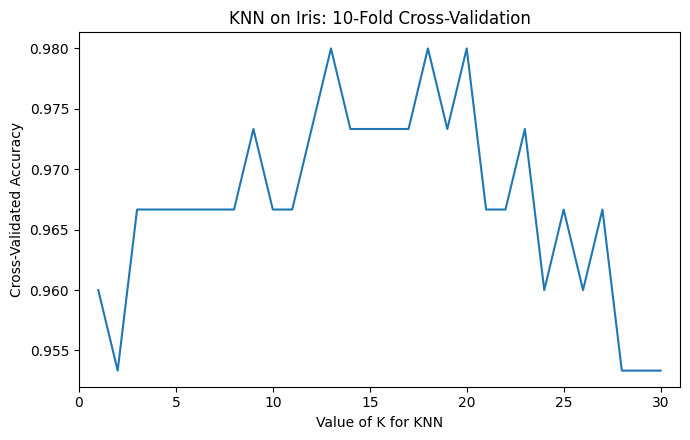

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(k_range), k_scores, color="tab:blue", linewidth=1.5)
ax.set_xlabel("Value of K for KNN")
ax.set_ylabel("Cross-Validated Accuracy")
ax.set_title("KNN on Iris: 10-Fold Cross-Validation")
ax.set_xlim(0, 31)
ax.set_xticks(range(0, 31, 5))
fig.tight_layout()
plt.show()

## 6. Graph 2 — Close-up of k=11 through 15

This second graph matches the requested close-up. It shows that k=13 performs better than its immediate neighbors in this interval.

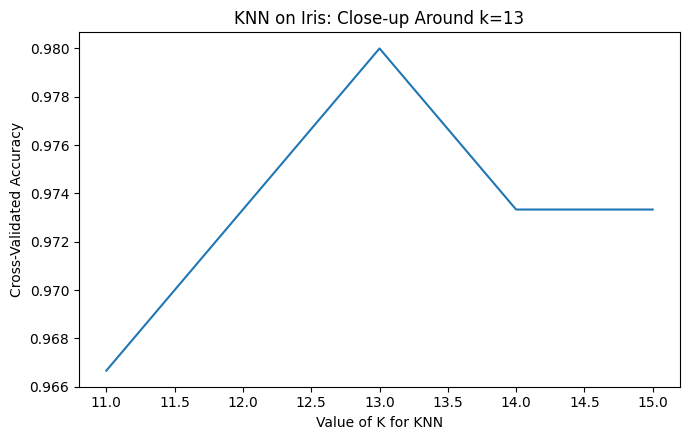

In [6]:
zoom_results = results.loc[results["k"].between(11, 15)]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(zoom_results["k"], zoom_results["mean_cv_accuracy"],
        color="tab:blue", linewidth=1.5)
ax.set_xlabel("Value of K for KNN")
ax.set_ylabel("Cross-Validated Accuracy")
ax.set_title("KNN on Iris: Close-up Around k=13")
ax.set_xticks(np.arange(11, 15.1, 0.5))
fig.tight_layout()
plt.show()

## 7. Confirm the result using GridSearchCV

GridSearchCV evaluates the same 30 candidate values with the same `cv=10` setting. Explicit `scoring="accuracy"` matches the classifier's default score used in the manual loop. The search refits the selected estimator on all available data after cross-validation.

When multiple candidates have the same best score, GridSearchCV selects the first candidate with the best rank. With this ascending parameter list, k=13 is selected before k=18 and k=20.

In [7]:
param_grid = {"n_neighbors": list(k_range)}
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    refit=True
)
grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print(f"Best mean CV accuracy: {grid_search.best_score_:.6f} ({grid_search.best_score_:.2%})")
print("Best estimator:", grid_search.best_estimator_)

grid_results = pd.DataFrame({
    "k": [params["n_neighbors"] for params in grid_search.cv_results_["params"]],
    "mean_cv_accuracy": grid_search.cv_results_["mean_test_score"],
    "rank": grid_search.cv_results_["rank_test_score"]
})
print("\nTop-ranked candidates:")
print(grid_results.loc[grid_results["rank"] == 1].to_string(index=False))

Best parameters: {'n_neighbors': 13}
Best mean CV accuracy: 0.980000 (98.00%)
Best estimator: KNeighborsClassifier(n_neighbors=13)

Top-ranked candidates:
 k  mean_cv_accuracy  rank
13              0.98     1
18              0.98     1
20              0.98     1


## 8. Verify consistency between both approaches

In [8]:
assert X.shape == (150, 4)
assert len(k_scores) == 30
assert all(len(scores) == 10 for scores in fold_scores_by_k)
np.testing.assert_allclose(
    results["mean_cv_accuracy"],
    grid_results["mean_cv_accuracy"],
    rtol=0, atol=1e-12
)
assert grid_search.best_params_["n_neighbors"] == best_k
assert np.isclose(grid_search.best_score_, best_accuracy)
print("Verification passed: all 30 manual CV scores match GridSearchCV.")
print(f"Confirmed selected parameter: k={best_k}; mean CV accuracy={best_accuracy:.2%}.")

Verification passed: all 30 manual CV scores match GridSearchCV.
Confirmed selected parameter: k=13; mean CV accuracy=98.00%.
